# Thymus Preprocessing for Annotated GSE240016

This dataset is already annotated and already contains UMAP and Leiden results. This notebook preserves the published annotation, performs QC visualization, maps `stage` into `age_group` for downstream compatibility, and saves a processed object without re-clustering.

## 1. Setup

We load the published annotated H5AD, define project paths, and set a random seed for reproducibility even though clustering is skipped.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc

np.random.seed(0)
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=120, facecolor="white")

PROJECT_ROOT = Path("..").resolve()
RAW_PATH = PROJECT_ROOT / "data" / "raw" / "GSE240016_CD45neg_thymic_stroma_d0+annotation.h5ad"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## 2. Load Existing Annotated Dataset

The source file is loaded fully because downstream notebooks use the saved processed object directly. The dataset already includes `cell_type`, `cell_type_subset`, multiple Leiden resolutions, PCA/Harmony coordinates, and UMAP.

In [2]:
if not RAW_PATH.exists():
    raise FileNotFoundError(f"Missing raw dataset: {RAW_PATH}")

adata = sc.read_h5ad(RAW_PATH)
adata.var_names_make_unique()
print(adata)
print("obs columns:", adata.obs.columns.tolist())
print("obsm keys:", list(adata.obsm.keys()))

AnnData object with n_obs × n_vars = 22932 × 27657
    obs: 'sample', 'stage', 'day', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'original_total_counts', 'log10_original_total_counts', 'mito_frac', 'ribo_frac', 'hb_frac', 'doublet_score', 'predicted_doublet', 'n_counts', 'leiden_0.2', 'leiden_0.4', 'leiden_0.6', 'leiden_0.8', 'leiden_1.0', 'leiden_1.2', 'leiden_1.4', 'leiden_1.6', 'leiden_1.8', 'leiden_2.0', 'leiden_0.1', 'leiden_0.3', 'leiden_0.5', 'leiden_0.7', 'leiden_0.9', 'cell_type', 'cell_type_subset'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'mt', 'ribo', 'hb', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'cell_type_colors', 'cell_type_subset_colors', 'day_colors', 'hvg', 'leiden', 'leiden_0.1

## 3. Age Group Mapping

The dataset uses `stage` for age, with `02mo` and `18mo`. We keep `stage` as the primary age column and also create `age_group` as an alias so existing validation scripts and downstream notebooks can work consistently.

In [3]:
if "stage" not in adata.obs.columns:
    raise KeyError("Expected adata.obs['stage'] with values such as 02mo and 18mo.")

adata.obs["age_group"] = adata.obs["stage"].astype("category")
print(adata.obs["stage"].value_counts())

stage
18mo    11970
02mo    10962
Name: count, dtype: int64


## 4. QC Visualization Before Filtering

The published object already contains QC metrics. We use `n_genes_by_counts` and `mito_frac` directly rather than recomputing mitochondrial percentages. These plots document the input QC state.

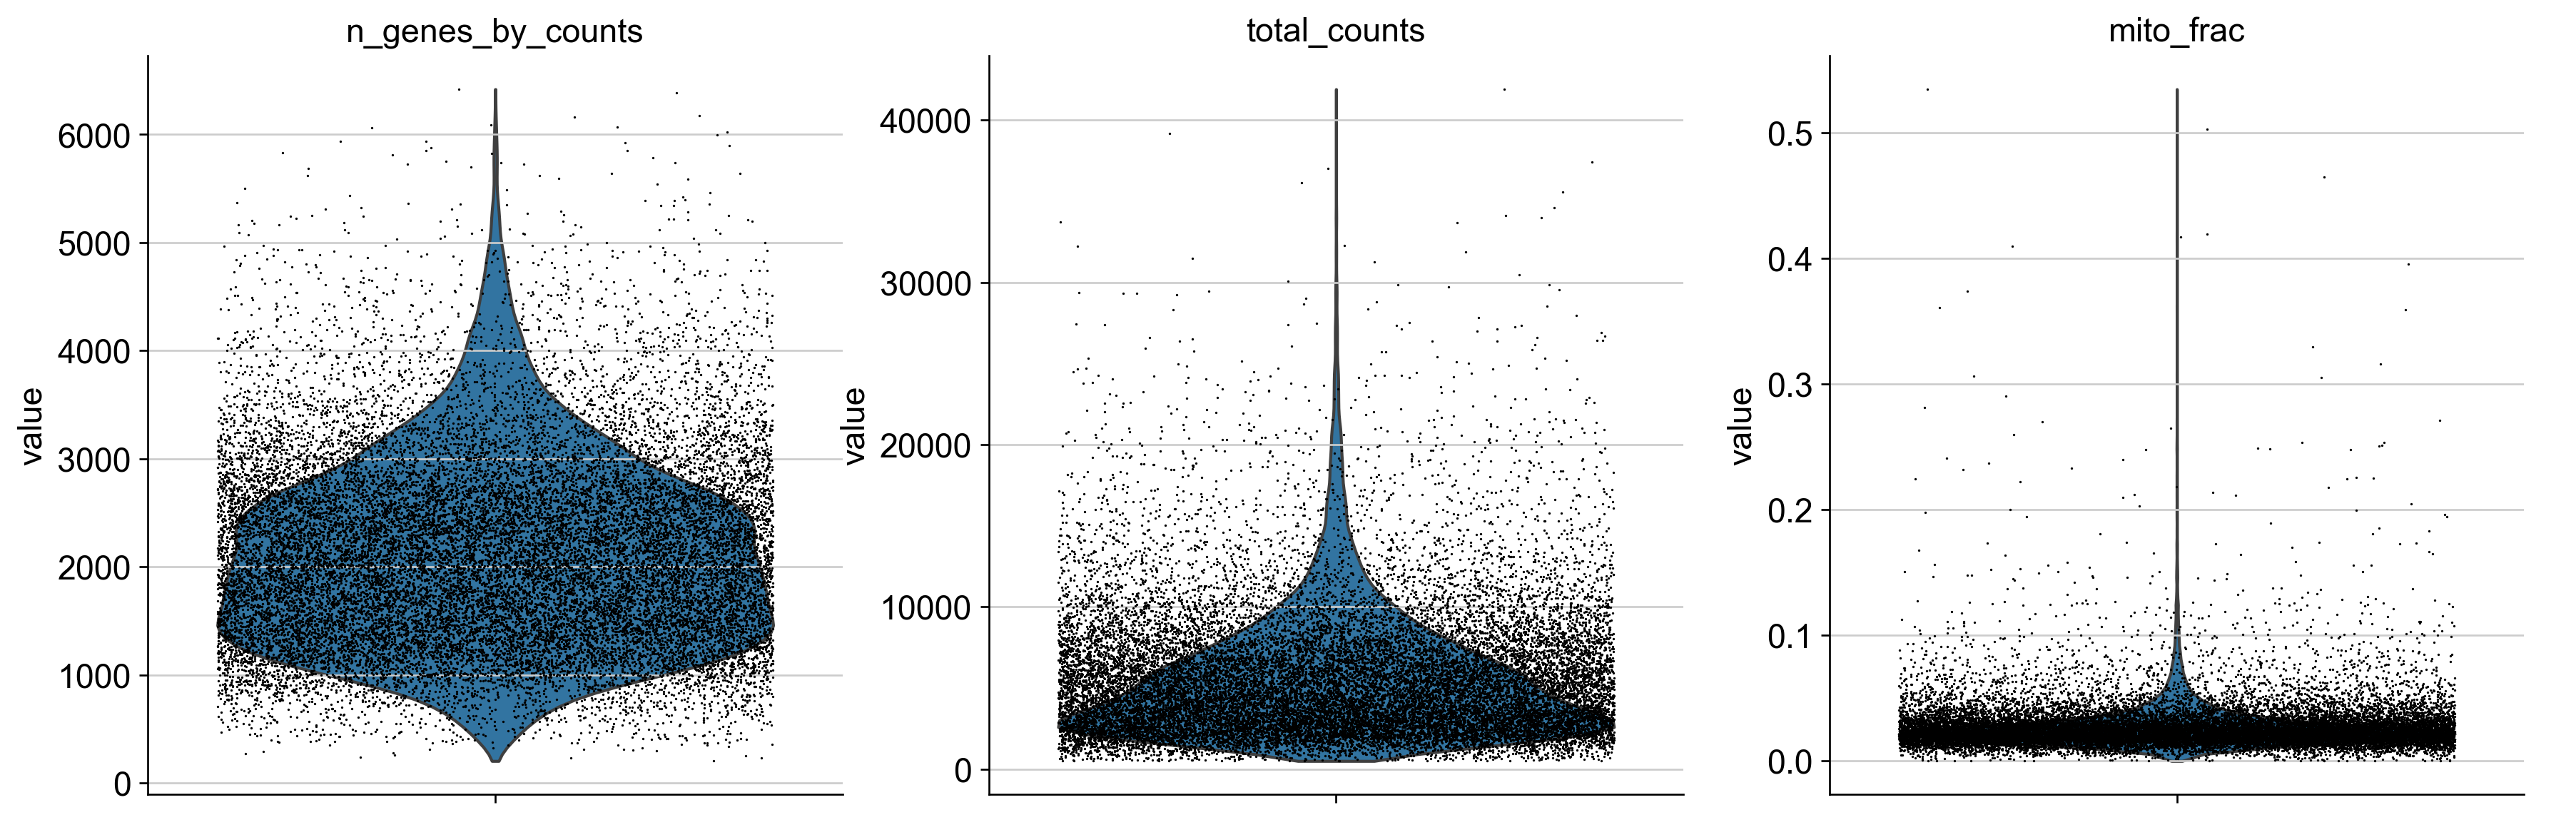

In [4]:
qc_columns = ["n_genes_by_counts", "total_counts", "mito_frac"]
missing_qc = [col for col in qc_columns if col not in adata.obs.columns]
if missing_qc:
    raise KeyError(f"Missing expected QC columns: {missing_qc}")

sc.pl.violin(adata, qc_columns, jitter=0.4, multi_panel=True, show=False)
plt.savefig(FIGURES_DIR / "qc_before_filtering_violin.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. Light QC Filtering

The published dataset is already quality controlled and annotated. We apply only broad thresholds: keep cells with 200-6000 detected genes and mitochondrial fraction <= 0.20, then remove genes detected in fewer than 3 cells.

In [5]:
n_cells_before = adata.n_obs
n_genes_before = adata.n_vars

adata = adata[(adata.obs["n_genes_by_counts"] >= 200) & (adata.obs["n_genes_by_counts"] <= 6000) & (adata.obs["mito_frac"] <= 0.20)].copy()
sc.pp.filter_genes(adata, min_cells=3)
adata.obs["age_group"] = adata.obs["stage"].astype("category")

print(f"Cells before filtering: {n_cells_before:,}")
print(f"Cells after filtering:  {adata.n_obs:,}")
print(f"Genes before filtering: {n_genes_before:,}")
print(f"Genes after filtering:  {adata.n_vars:,}")

filtered out 2446 genes that are detected in less than 3 cells


Cells before filtering: 22,932
Cells after filtering:  22,877
Genes before filtering: 27,657
Genes after filtering:  25,211


## 6. QC Visualization After Filtering

The same QC metrics are plotted after filtering and saved to `figures/` for auditability.

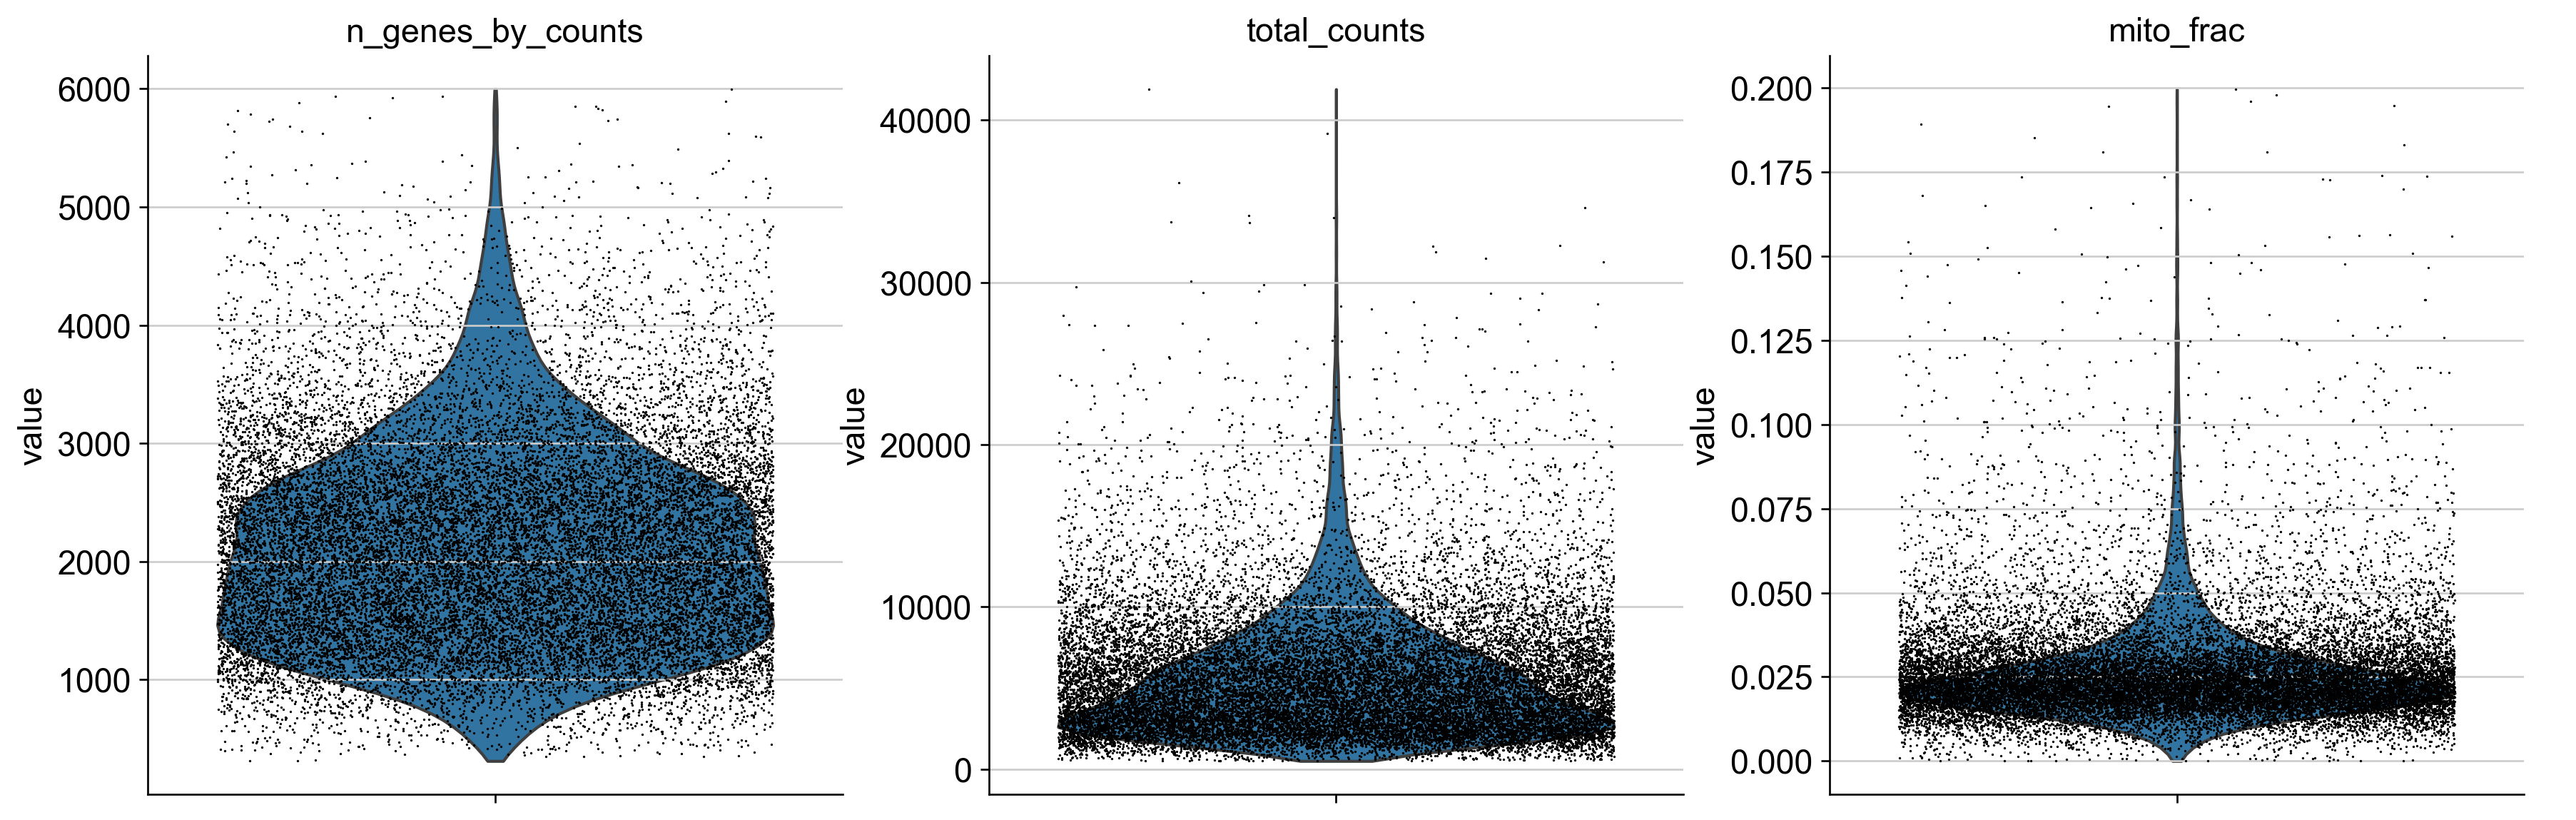

In [6]:
sc.pl.violin(adata, qc_columns, jitter=0.4, multi_panel=True, show=False)
plt.savefig(FIGURES_DIR / "qc_after_filtering_violin.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Preserve Existing UMAP and Clusters

The dataset already contains `X_umap` and many Leiden resolutions, so this notebook does not recompute neighbors, UMAP, or Leiden clustering.

Using existing UMAP coordinates: adata.obsm['X_umap']
Existing Leiden columns: ['leiden_0.2', 'leiden_0.4', 'leiden_0.6', 'leiden_0.8', 'leiden_1.0', 'leiden_1.2', 'leiden_1.4', 'leiden_1.6', 'leiden_1.8', 'leiden_2.0', 'leiden_0.1', 'leiden_0.3', 'leiden_0.5', 'leiden_0.7', 'leiden_0.9']


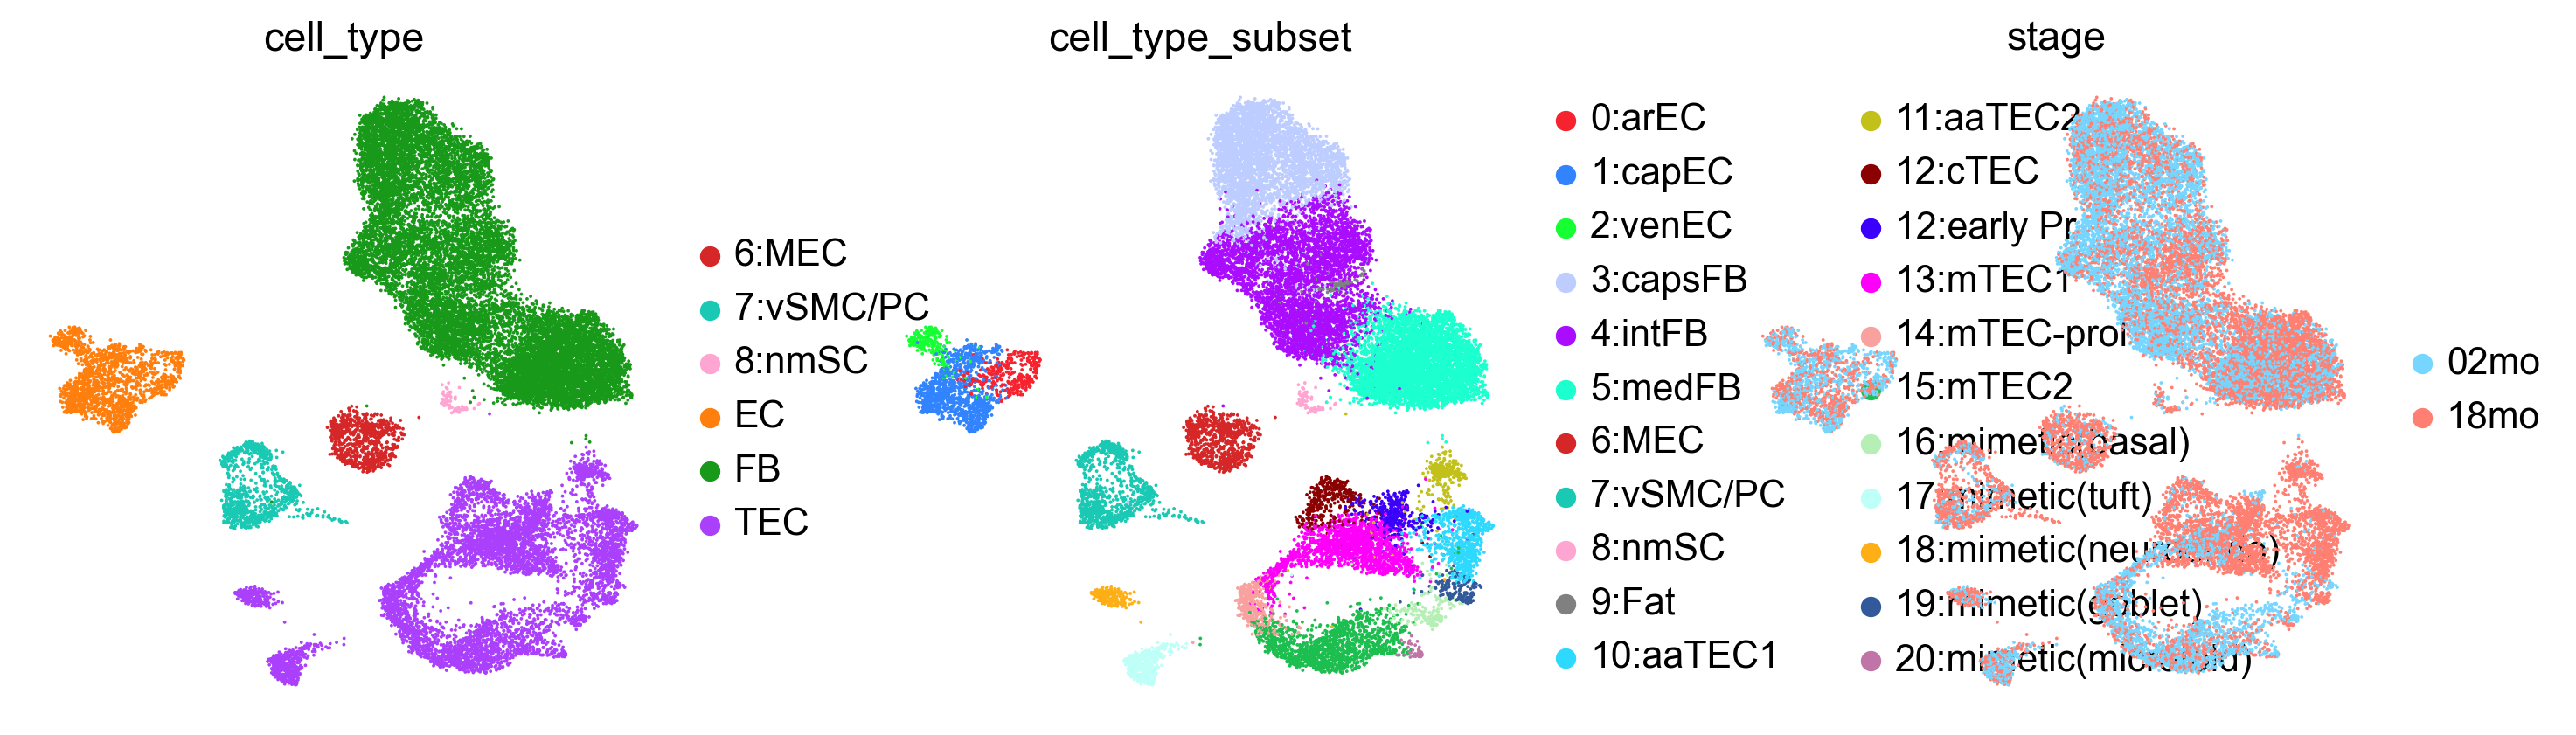

In [7]:
if "X_umap" in adata.obsm:
    print("Using existing UMAP coordinates: adata.obsm['X_umap']")
else:
    raise KeyError("Expected existing UMAP coordinates in adata.obsm['X_umap']; not recomputing by design.")

leiden_cols = [col for col in adata.obs.columns if col.startswith("leiden_")]
print("Existing Leiden columns:", leiden_cols)

sc.pl.umap(adata, color=["cell_type", "cell_type_subset", "stage"], ncols=3, frameon=False, show=False)
plt.savefig(FIGURES_DIR / "existing_umap_annotations_stage.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Save Processed Object

The processed object keeps the published annotation and embedding, plus the `age_group` alias for `stage`.

In [8]:
output_path = PROCESSED_DIR / "thymus_preprocessed.h5ad"
adata.write(output_path)
print(f"Saved processed object to: {output_path}")

Saved processed object to: D:\ThymusLOXScan\data\processed\thymus_preprocessed.h5ad
